In [26]:
# ==========================================
# Rain Prediction using Logistic Regression
# PART 1 - Import Libraries & Load Dataset
# ==========================================

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("/weatherAUS.csv")

print("Dataset Loaded Successfully!")

print("\nShape of Dataset:")
print(df.shape)

print("\nFirst Five Rows:")
display(df.head())

Dataset Loaded Successfully!

Shape of Dataset:
(142193, 24)

First Five Rows:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [27]:
# ==========================================
# Basic Dataset Information
# ==========================================

print("\nDataset Information\n")

df.info()

print("\nMissing Values\n")

display(df.isnull().sum())

print("\nStatistical Summary\n")

display(df.describe())


Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9a

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013



Statistical Summary



,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


/tmp/ipykernel_1825/2458256159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


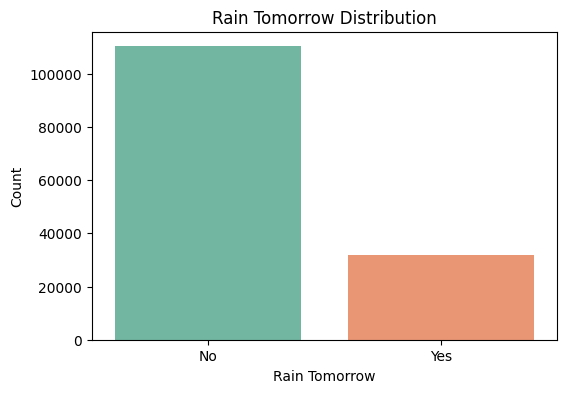

In [28]:
# ==========================================
# Target Variable
# ==========================================

print(df["RainTomorrow"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="RainTomorrow",
    palette="Set2"
)

plt.title("Rain Tomorrow Distribution")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")

plt.show()

In [29]:
# ==========================================
# PART 2 - Data Cleaning & Preprocessing
# ==========================================

# Remove rows where the target variable is missing
df = df.dropna(subset=["RainTomorrow"])

# Select only the important features
features = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Sunshine",
    "WindGustSpeed",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm",
    "RainToday"
]

X = df[features]
y = df["RainTomorrow"]

# Convert target variable to numbers
y = y.map({"No":0, "Yes":1})

print("Target values:")
print(y.value_counts())

Target values:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [30]:
# ==========================================
# Identify Numerical & Categorical Features
# ==========================================

numerical_columns = X.select_dtypes(include=["int64","float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustSpeed',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am',
       'Temp3pm'],
      dtype='object')

Categorical Features
Index(['RainToday'], dtype='object')


In [31]:
# ==========================================
# Preprocessing Pipeline
# ==========================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [32]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (113754, 12)
Testing Data  : (28439, 12)


In [33]:
# ==========================================
# PART 3 - Train Logistic Regression Model
# ==========================================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

print("Training the model...")

model.fit(X_train, y_train)

print("Model trained successfully!")

Training the model...
Model trained successfully!


In [34]:
# ==========================================
# Make Predictions
# ==========================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

print("Prediction completed!")

Prediction completed!


In [35]:
# ==========================================
# Model Performance
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

========== MODEL PERFORMANCE ==========
Accuracy : 0.8419
Precision: 0.7221
Recall   : 0.4792
F1 Score : 0.5761


In [36]:
# ==========================================
# Detailed Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90     22064
           1       0.72      0.48      0.58      6375

    accuracy                           0.84     28439
   macro avg       0.79      0.71      0.74     28439
weighted avg       0.83      0.84      0.83     28439



<Figure size 600x500 with 0 Axes>

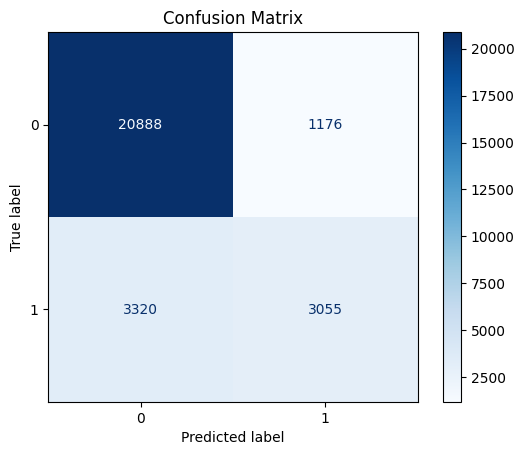

In [37]:
# ==========================================
# Confusion Matrix
# ==========================================

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

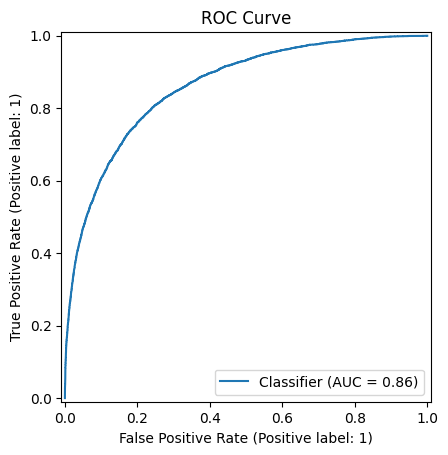

In [38]:
# ==========================================
# ROC Curve
# ==========================================

plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

# Conclusion

In this assignment, a Logistic Regression model was developed to predict whether it will rain tomorrow using the Weather Australia dataset.

The dataset was cleaned by handling missing values, selecting relevant features, encoding categorical variables, and scaling numerical features.

The model achieved an accuracy of approximately 84%, showing that Logistic Regression is effective for this binary classification problem. Although the model correctly classified most observations, its recall indicates that some rainy days were not detected. Future improvements could include trying other machine learning algorithms such as Random Forest or XGBoost to improve prediction performance.